<a href="https://colab.research.google.com/github/narendrabrahma/Titanic-data-cleaning/blob/main/Titanic_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Titanic_train.csv")

In [5]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [6]:
print("Number of rows: ", df.shape[0])
print("Number of colunns: ",df.shape[1])

Number of rows:  891
Number of colunns:  12


In [7]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [8]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [9]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [10]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


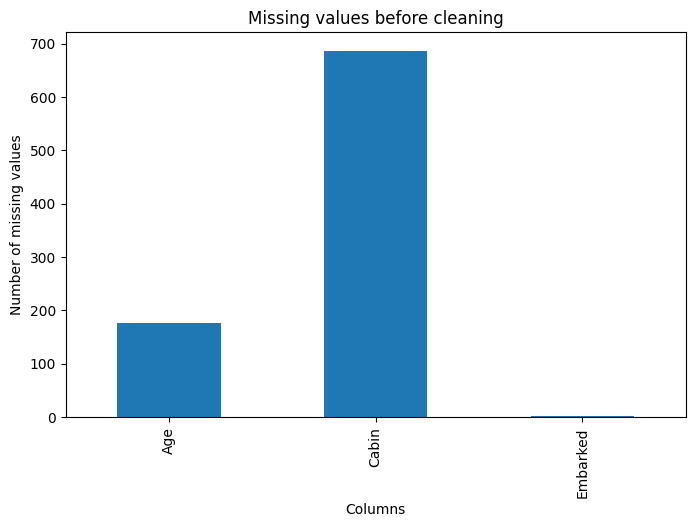

In [11]:
missing = df.isnull().sum()
missing = missing[missing>0]
plt.figure(figsize=(8,5))
missing.plot(kind="bar")

plt.title("Missing values before cleaning")
plt.xlabel("Columns")
plt.ylabel("Number of missing values")

plt.show()

In [12]:
missing_count = df.isnull().sum()

missing_percentage = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_count,
    "Percentage": missing_percentage
})

print(missing_table[missing_table["Missing Values"] > 0])

          Missing Values  Percentage
Age                  177   19.865320
Cabin                687   77.104377
Embarked               2    0.224467


In [13]:
print("Median Age:", df["Age"].median())

Median Age: 28.0


In [14]:
print("Missing Age before:", df["Age"].isnull().sum())

df["Age"] = df["Age"].fillna(df["Age"].median())

print("Missing Age after:", df["Age"].isnull().sum())

Missing Age before: 177
Missing Age after: 0


In [15]:
print("Missing Cabin values: ", df["Cabin"].isnull().sum())

Missing Cabin values:  687


In [16]:
df = df.drop(columns = ["Cabin"])

In [17]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


In [18]:
print("Most common embarked value:",df["Embarked"].mode()[0])

Most common embarked value: S


In [19]:
print("Missing Embarked before:", df["Embarked"].isnull().sum())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("Missing Embarked after:", df["Embarked"].isnull().sum())

Missing Embarked before: 2
Missing Embarked after: 0


In [20]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [21]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [22]:
df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


In [23]:
print("Survived values:", df["Survived"].unique())

Survived values: [0 1]


In [24]:
print("Invalid Survived values:",
      (~df["Survived"].isin([0, 1])).sum())

Invalid Survived values: 0


In [25]:
print("Pclass values:", sorted(df["Pclass"].unique()))

print("Invalid Pclass values:",
      (~df["Pclass"].isin([1, 2, 3])).sum())

Pclass values: [np.int64(1), np.int64(2), np.int64(3)]
Invalid Pclass values: 0


In [26]:
print("Sex values:", df["Sex"].unique())

print("Invalid Sex values:",
      (~df["Sex"].isin(["male", "female"])).sum())

Sex values: ['male' 'female']
Invalid Sex values: 0


In [27]:
print("Embarked values:", df["Embarked"].unique())

print("Invalid Embarked values:",
      (~df["Embarked"].isin(["C", "Q", "S"])).sum())

Embarked values: ['S' 'C' 'Q']
Invalid Embarked values: 0


In [28]:
print("Minimun Age: ", df["Age"].min())
print("Maximum Age: ",df["Age"].max())

Minimun Age:  0.42
Maximum Age:  80.0


In [29]:
invalid_age = df[(df["Age"] < 0) | (df["Age"] > 100)]
print("Invalid Age records: ", len(invalid_age))

Invalid Age records:  0


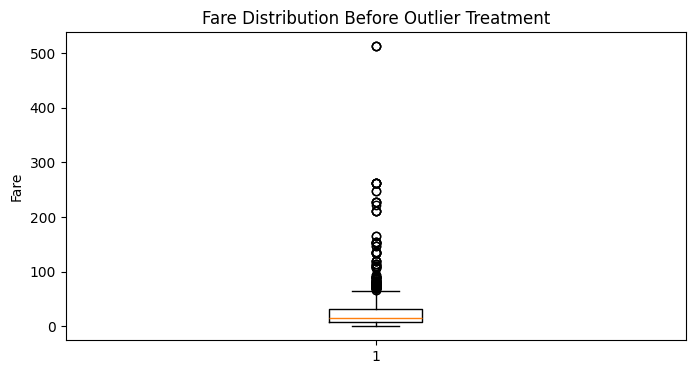

In [30]:
plt.figure(figsize=(8, 4))

plt.boxplot(df["Fare"])

plt.title("Fare Distribution Before Outlier Treatment")
plt.ylabel("Fare")

plt.show()

In [31]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 7.9104
Q3: 31.0
IQR: 23.0896


In [32]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -26.724
Upper Bound: 65.6344


In [33]:
outliers = df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 116


In [34]:
print(outliers[["PassengerId", "Pclass", "Fare"]].head(20))

     PassengerId  Pclass      Fare
1              2       1   71.2833
27            28       1  263.0000
31            32       1  146.5208
34            35       1   82.1708
52            53       1   76.7292
61            62       1   80.0000
62            63       1   83.4750
72            73       2   73.5000
88            89       1  263.0000
102          103       1   77.2875
118          119       1  247.5208
120          121       2   73.5000
124          125       1   77.2875
139          140       1   79.2000
151          152       1   66.6000
159          160       3   69.5500
180          181       3   69.5500
195          196       1  146.5208
201          202       3   69.5500
215          216       1  113.2750


In [35]:
df["Fare"] = df["Fare"].clip(
    lower=lower_bound,
    upper=upper_bound
)

In [36]:
print("Maximum Fare after treatment:", df["Fare"].max())

Maximum Fare after treatment: 65.6344


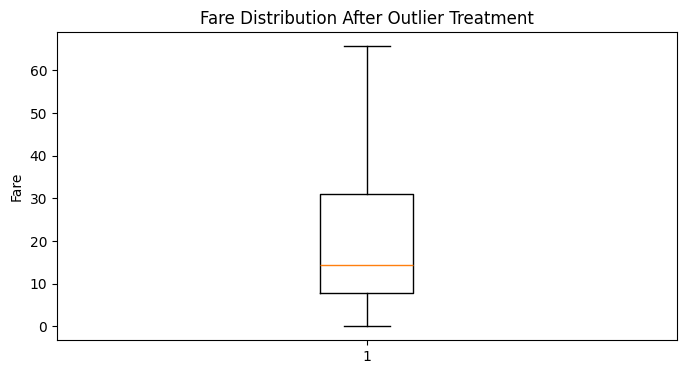

In [37]:
plt.figure(figsize=(8, 4))

plt.boxplot(df["Fare"])

plt.title("Fare Distribution After Outlier Treatment")
plt.ylabel("Fare")

plt.show()

In [38]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1


In [39]:
print(df[["SibSp", "Parch", "FamilySize"]].head(10))

   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1
5      0      0           1
6      0      0           1
7      3      1           5
8      0      2           3
9      1      0           2


In [40]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [41]:
print(df[["FamilySize", "IsAlone"]].head(10))

   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1
5           1        1
6           1        1
7           5        0
8           3        0
9           2        0


In [42]:
print(df.shape)
print(df.columns)

(891, 13)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize', 'IsAlone'],
      dtype='object')


In [43]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
IsAlone        0
dtype: int64


In [44]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  FamilySize     IsAlone  
count  891.000000  891.000000  891.000000  891.000000  
mean     0.381594   24.046813    1.904602    0.602694  
std      0.806057   20.481625    1.613459    0.489615  
min      0.000000    0.000000    1.000000    0.000000  
25%      0.000000    7.910400    1.000000    0.000000  
50%      0.000000   14.454200    

In [45]:
df.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [46]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  FamilySize  IsAlone  
0      0         A/5 21171   7.2500        S           2        0  
1      0          PC 17599  65.6344        C           2        0  
2      0  STON/O2. 3101282   7.9250        S           1        1  
3      0            113803  53.1000        S    

In [47]:
print("Final dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())

Final dataset shape: (891, 13)
Total missing values: 0


In [48]:
print("Final dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows of cleaned data:")
print(df.head())

print("\nFinal columns:")
print(df.columns.tolist())

# Save cleaned dataset
df.to_csv("titanic_cleaned.csv", index=False)

print("\nCleaned dataset saved successfully!")

Final dataset shape: (891, 13)

Missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
IsAlone        0
dtype: int64

First 5 rows of cleaned data:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parc